# Advanced Environmental Analysis

This notebook analyzes the trusted Gold analytical views:

- `gold.vw_environment_hourly`
- `gold.vw_environment_daily`

Objectives:

1. Analyze environmental trends
2. Measure city-level variability
3. Identify relationships between weather and air quality
4. Detect pollution patterns and anomalies
5. Prepare insights for forecasting

# Section 1 — Load Analytical Data

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.database.sql_server import get_sql_connection

In [2]:
#Connect to SQL Server
conn = get_sql_connection()

print("SQL Server connection established.")

SQL Server connection established.


In [3]:
#Load Hourly Data
hourly_query = """
SELECT *
FROM gold.vw_environment_hourly
ORDER BY observation_hour
"""

hourly_df = pd.read_sql(
    hourly_query,
    conn
)

print("Hourly records:", len(hourly_df))
print("Columns:", len(hourly_df.columns))

hourly_df.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_24284\3546389474.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  hourly_df = pd.read_sql(


Hourly records: 1425
Columns: 26


,city_key,observation_hour,observation_count,avg_temperature_c,min_temperature_c,max_temperature_c,avg_feels_like_c,avg_humidity_pct,avg_pressure_hpa,avg_visibility_m,...,avg_pm2_5,max_pm2_5,avg_pm10,max_pm10,avg_co,avg_no,avg_no2,avg_o3,avg_so2,avg_nh3
0,1,2026-08-23 10:00:00,7,28.448571,28.02,29.02,30.848571,65.571428,1003.428571,10000.0,...,6.284285,6.29,11.775714,12.08,87.637142,0.111428,1.148571,43.428571,0.971428,0.182857
1,2,2026-08-23 10:00:00,8,27.716250,27.39,27.93,30.221250,70.875000,1009.250000,10000.0,...,2.762500,2.92,4.442500,4.63,114.186250,0.685000,2.341250,34.341250,0.861250,3.386250
2,3,2026-08-23 10:00:00,7,29.180000,29.18,29.18,33.467142,71.714285,1005.285714,10000.0,...,14.610000,14.94,16.187142,16.53,142.670000,0.065714,2.567142,42.351428,0.847142,1.171428
3,4,2026-08-23 10:00:00,8,29.976250,29.95,29.98,36.357500,75.875000,999.625000,10000.0,...,29.995000,31.77,31.297500,32.96,210.501250,0.138750,3.213750,78.088750,2.028750,0.518750
4,5,2026-08-23 10:00:00,8,32.516250,32.29,32.83,39.516250,67.125000,1004.750000,10000.0,...,16.142500,17.08,18.480000,19.62,140.010000,0.537500,3.620000,66.868750,7.542500,4.046250


In [4]:
#Load Daily Data
daily_query = """
SELECT *
FROM gold.vw_environment_daily
ORDER BY observation_date
"""

daily_df = pd.read_sql(
    daily_query,
    conn
)

print("Daily records:", len(daily_df))
print("Columns:", len(daily_df.columns))

daily_df.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_24284\2137605635.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  daily_df = pd.read_sql(


Daily records: 160
Columns: 28


,city_key,observation_date,observation_count,avg_temperature_c,min_temperature_c,max_temperature_c,temperature_stddev_c,avg_feels_like_c,avg_humidity_pct,avg_pressure_hpa,...,avg_pm2_5,max_pm2_5,avg_pm10,max_pm10,avg_co,avg_no,avg_no2,avg_o3,avg_so2,avg_nh3
0,19,2026-08-23,60,29.732333,27.90,31.71,1.113027,33.931666,69.033333,1011.483333,...,7.981000,9.99,15.645000,18.59,88.489500,0.000500,0.484833,54.992666,0.337166,0.821166
1,10,2026-08-23,60,32.998333,30.68,33.69,0.833014,36.708500,51.583333,1003.383333,...,11.105500,12.00,19.783500,20.91,157.001833,0.135500,6.169166,50.398000,0.638166,4.656833
2,17,2026-08-23,60,30.446333,28.98,31.98,0.650322,37.433000,79.583333,1000.800000,...,40.173500,51.33,44.640500,57.91,511.653166,0.065833,5.743833,46.856333,2.393333,4.141500
3,5,2026-08-23,60,30.680666,26.40,32.83,1.964543,36.839333,74.866666,1005.983333,...,13.504833,17.29,16.113000,20.24,178.203500,0.266000,9.526000,51.436166,9.224000,4.488500
4,12,2026-08-23,60,29.875166,27.95,31.96,1.465243,36.715666,87.000000,999.950000,...,28.791333,37.96,31.552666,42.92,256.474000,0.072333,2.602166,81.463500,1.399500,2.924166


In [5]:
#Convert Date Columns
hourly_df["observation_hour"] = pd.to_datetime(
    hourly_df["observation_hour"]
)

daily_df["observation_date"] = pd.to_datetime(
    daily_df["observation_date"]
)

In [6]:
print(hourly_df["observation_hour"].dtype)
print(daily_df["observation_date"].dtype)

datetime64[ns]
datetime64[ns]


In [7]:
#Basic Data Coverage
print("HOURLY DATA")
print("-" * 40)

print(
    "Start:",
    hourly_df["observation_hour"].min()
)

print(
    "End:",
    hourly_df["observation_hour"].max()
)

print(
    "Cities:",
    hourly_df["city_key"].nunique()
)

print(
    "Records:",
    len(hourly_df)
)

HOURLY DATA
----------------------------------------
Start: 2026-08-23 10:00:00
End: 2026-08-30 14:00:00
Cities: 20
Records: 1425


In [8]:
print("\nDAILY DATA")
print("-" * 40)

print(
    "Start:",
    daily_df["observation_date"].min()
)

print(
    "End:",
    daily_df["observation_date"].max()
)

print(
    "Cities:",
    daily_df["city_key"].nunique()
)

print(
    "Records:",
    len(daily_df)
)


DAILY DATA
----------------------------------------
Start: 2026-08-23 00:00:00
End: 2026-08-30 00:00:00
Cities: 20
Records: 160


In [9]:
#Data Coverage by City
city_coverage = (
    hourly_df
    .groupby("city_key")
    .agg(
        hourly_records=(
            "observation_hour",
            "count"
        ),
        first_observation=(
            "observation_hour",
            "min"
        ),
        last_observation=(
            "observation_hour",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "hourly_records",
        ascending=False
    )
)

city_coverage

,city_key,hourly_records,first_observation,last_observation
15,16,74,2026-08-23 10:00:00,2026-08-30 14:00:00
6,7,73,2026-08-23 10:00:00,2026-08-30 14:00:00
11,12,73,2026-08-23 10:00:00,2026-08-30 14:00:00
4,5,72,2026-08-23 10:00:00,2026-08-30 14:00:00
5,6,72,2026-08-23 10:00:00,2026-08-30 14:00:00
9,10,72,2026-08-23 10:00:00,2026-08-30 14:00:00
0,1,71,2026-08-23 10:00:00,2026-08-30 14:00:00
16,17,71,2026-08-23 10:00:00,2026-08-30 14:00:00
2,3,71,2026-08-23 10:00:00,2026-08-30 14:00:00
3,4,71,2026-08-23 10:00:00,2026-08-30 14:00:00


In [10]:
#Expected vs Actual Hourly Coverage
hourly_df["observation_date"] = (
    hourly_df["observation_hour"].dt.date
)

coverage_by_day = (
    hourly_df
    .groupby("observation_date")
    .agg(
        total_hourly_records=(
            "observation_hour",
            "count"
        ),
        cities=(
            "city_key",
            "nunique"
        )
    )
    .reset_index()
)

coverage_by_day

,observation_date,total_hourly_records,cities
0,2026-08-23,145,20
1,2026-08-24,140,20
2,2026-08-25,220,20
3,2026-08-26,180,20
4,2026-08-27,191,20
5,2026-08-28,199,20
6,2026-08-29,184,20
7,2026-08-30,166,20


In [11]:
#Basic Statistical Summary
analysis_columns = [
    "avg_temperature_c",
    "min_temperature_c",
    "max_temperature_c",
    "avg_humidity_pct",
    "avg_pressure_hpa",
    "avg_wind_speed_mps",
    "rainfall_1h_mm",
    "avg_aqi",
    "avg_pm2_5",
    "avg_pm10"
]

hourly_df[analysis_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
avg_temperature_c,1425.0,28.855389,4.439777,16.515000,26.180000,28.968000,30.980000,43.548461
min_temperature_c,1425.0,28.575846,4.426994,16.370000,25.990000,28.840000,30.910000,43.010000
max_temperature_c,1425.0,29.145614,4.494310,16.630000,26.570000,29.000000,31.050000,44.010000
avg_humidity_pct,1425.0,72.365263,16.645840,16.818181,62.000000,74.454545,85.200000,100.000000
avg_pressure_hpa,1425.0,1006.286682,5.332645,996.000000,1001.636363,1006.000000,1010.000000,1025.000000
avg_wind_speed_mps,1425.0,4.302867,2.471383,0.000000,2.728461,4.083333,5.460000,27.565714
rainfall_1h_mm,392.0,1.070179,1.797340,0.100000,0.170000,0.410000,1.190000,15.380000
avg_aqi,1425.0,1.979373,1.101895,1.000000,1.000000,2.000000,3.000000,5.000000
avg_pm2_5,1425.0,17.592147,19.601107,0.894000,4.272307,9.595000,23.770000,111.070000
avg_pm10,1425.0,33.918430,60.474295,1.501818,7.843076,14.095555,32.753333,478.645000


In [12]:
#City-Level Environmental Summary
city_summary = (
    hourly_df
    .groupby("city_key")
    .agg(
        avg_temperature_c=(
            "avg_temperature_c",
            "mean"
        ),

        min_temperature_c=(
            "min_temperature_c",
            "min"
        ),

        max_temperature_c=(
            "max_temperature_c",
            "max"
        ),

        temperature_stddev_c=(
            "avg_temperature_c",
            "std"
        ),

        avg_humidity_pct=(
            "avg_humidity_pct",
            "mean"
        ),

        avg_wind_speed_mps=(
            "avg_wind_speed_mps",
            "mean"
        ),

        avg_aqi=(
            "avg_aqi",
            "mean"
        ),

        avg_pm2_5=(
            "avg_pm2_5",
            "mean"
        ),

        max_pm2_5=(
            "max_pm2_5",
            "max"
        ),

        avg_pm10=(
            "avg_pm10",
            "mean"
        )
    )
    .reset_index()
)

city_summary

,city_key,avg_temperature_c,min_temperature_c,max_temperature_c,temperature_stddev_c,avg_humidity_pct,avg_wind_speed_mps,avg_aqi,avg_pm2_5,max_pm2_5,avg_pm10
0,1,29.873801,27.02,31.09,0.972530,58.003446,3.934240,1.207746,6.816683,11.97,14.587113
1,2,26.053885,21.56,29.83,2.071599,71.468866,4.928449,1.055698,6.377228,11.53,9.615673
2,3,25.007481,23.05,29.18,1.461452,87.300344,3.738456,1.361051,8.576472,19.13,10.145479
3,4,28.918784,25.91,32.98,2.051561,83.043120,2.636434,2.349368,24.287218,51.64,26.902101
4,5,31.959177,25.01,37.57,2.876930,70.965238,4.065638,1.771419,13.159365,28.17,16.781693
5,6,31.876056,26.99,35.99,2.559420,72.138526,3.082567,2.961401,30.479741,78.38,71.295425
6,7,40.262200,36.01,44.01,1.817456,33.446772,5.086335,4.874333,70.452584,103.90,267.678027
7,8,30.358449,27.95,36.00,2.325008,85.292407,1.898815,1.472828,9.057117,18.79,10.404153
8,9,27.671077,23.21,31.56,2.282658,71.307412,9.588224,1.106175,3.064691,6.53,4.113412
9,10,30.495466,25.68,33.69,2.436918,64.525947,3.472778,2.104630,12.960011,21.44,31.405907


In [13]:
#Identify Warmest Cities
warmest_cities = (
    city_summary
    .sort_values(
        "avg_temperature_c",
        ascending=False
    )
)

warmest_cities[
    [
        "city_key",
        "avg_temperature_c"
    ]
]

,city_key,avg_temperature_c
6,7,40.262200
4,5,31.959177
5,6,31.876056
16,17,31.427929
9,10,30.495466
7,8,30.358449
11,12,30.057942
0,1,29.873801
18,19,29.762570
13,14,29.627396


In [14]:
#Highest PM2.5 Cities
highest_pm25_cities = (
    city_summary
    .sort_values(
        "avg_pm2_5",
        ascending=False
    )
)

highest_pm25_cities[
    [
        "city_key",
        "avg_pm2_5",
        "max_pm2_5"
    ]
]

,city_key,avg_pm2_5,max_pm2_5
6,7,70.452584,103.90
11,12,42.831106,112.33
16,17,42.559919,77.35
13,14,31.012315,68.57
5,6,30.479741,78.38
3,4,24.287218,51.64
18,19,16.924394,31.78
4,5,13.159365,28.17
9,10,12.960011,21.44
7,8,9.057117,18.79


In [15]:
#Temperature Variability
temperature_variability = (
    city_summary
    .sort_values(
        "temperature_stddev_c",
        ascending=False
    )
)

temperature_variability[
    [
        "city_key",
        "avg_temperature_c",
        "temperature_stddev_c"
    ]
]


#This answers:
#Which monitored cities have the most variable temperatures during our observation period?

,city_key,avg_temperature_c,temperature_stddev_c
19,20,27.359539,3.405673
4,5,31.959177,2.876930
12,13,21.902567,2.697697
5,6,31.876056,2.559420
15,16,21.978632,2.517688
9,10,30.495466,2.436918
7,8,30.358449,2.325008
8,9,27.671077,2.282658
1,2,26.053885,2.071599
3,4,28.918784,2.051561


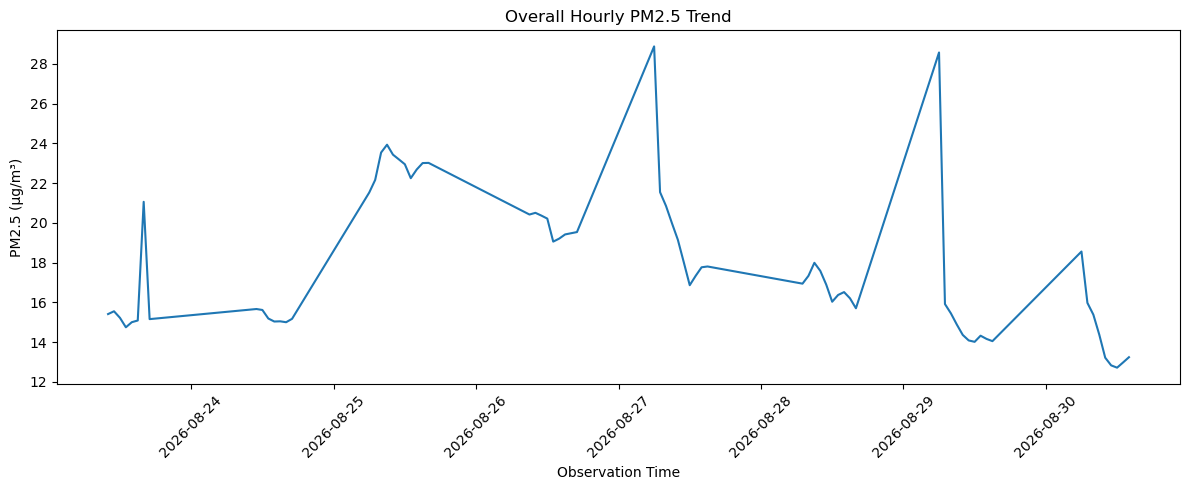

In [16]:
#PM2.5 Trend
pm25_trend = (
    hourly_df
    .groupby("observation_hour")
    ["avg_pm2_5"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    pm25_trend["observation_hour"],
    pm25_trend["avg_pm2_5"]
)

plt.title(
    "Overall Hourly PM2.5 Trend"
)

plt.xlabel("Observation Time")
plt.ylabel("PM2.5 (μg/m³)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

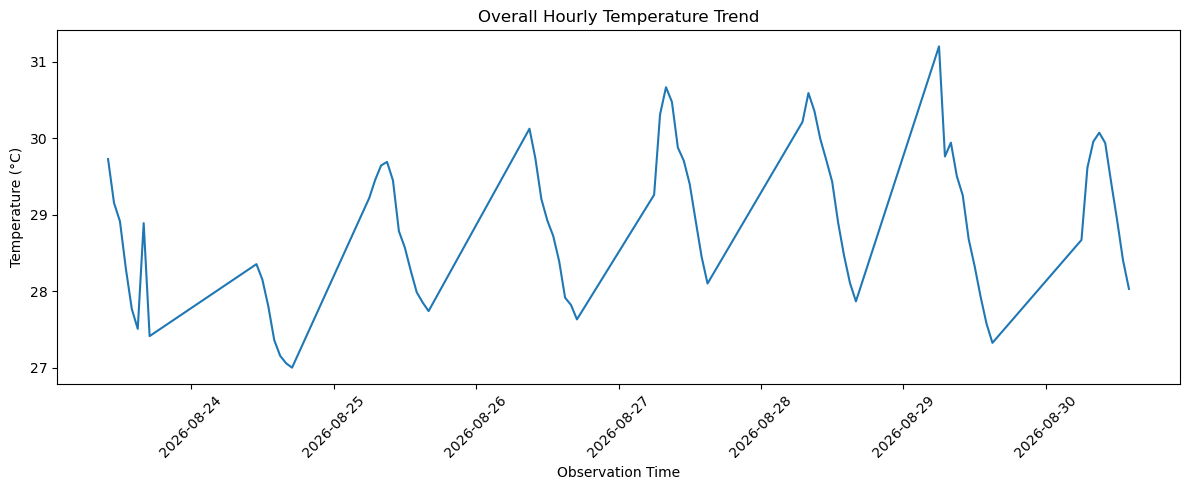

In [17]:
#Temperature Trend
temperature_trend = (
    hourly_df
    .groupby("observation_hour")
    ["avg_temperature_c"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    temperature_trend["observation_hour"],
    temperature_trend["avg_temperature_c"]
)

plt.title(
    "Overall Hourly Temperature Trend"
)

plt.xlabel("Observation Time")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
#6-Hour Rolling PM2.5
pm25_trend["pm25_rolling_6h"] = (
    pm25_trend["avg_pm2_5"]
    .rolling(
        window=6,
        min_periods=3
    )
    .mean()
)

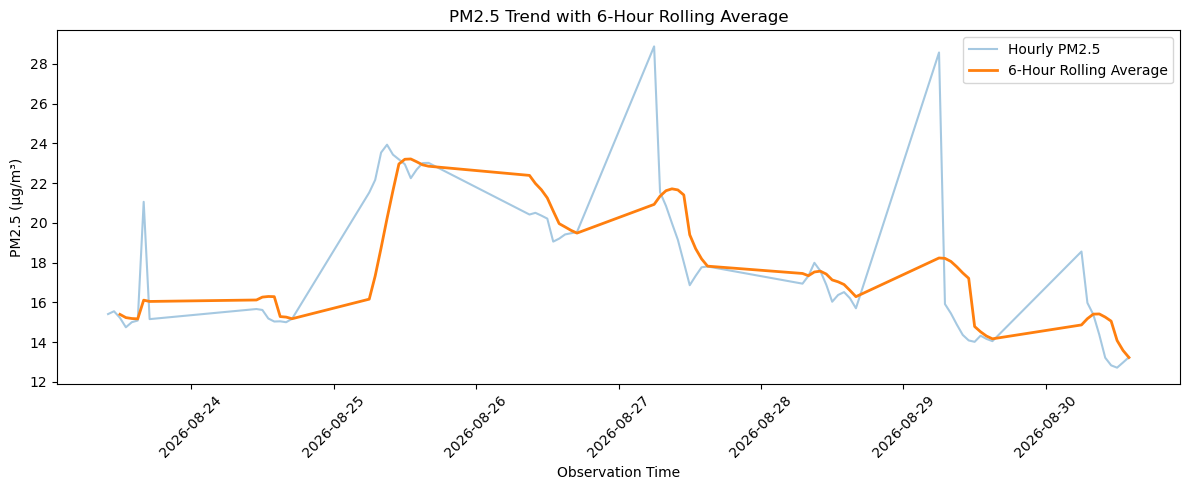

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    pm25_trend["observation_hour"],
    pm25_trend["avg_pm2_5"],
    alpha=0.4,
    label="Hourly PM2.5"
)

plt.plot(
    pm25_trend["observation_hour"],
    pm25_trend["pm25_rolling_6h"],
    linewidth=2,
    label="6-Hour Rolling Average"
)

plt.title(
    "PM2.5 Trend with 6-Hour Rolling Average"
)

plt.xlabel("Observation Time")
plt.ylabel("PM2.5 (μg/m³)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
#24-Hour Rolling PM2.5
pm25_trend["pm25_rolling_24h"] = (
    pm25_trend["avg_pm2_5"]
    .rolling(
        window=24,
        min_periods=6
    )
    .mean()
)

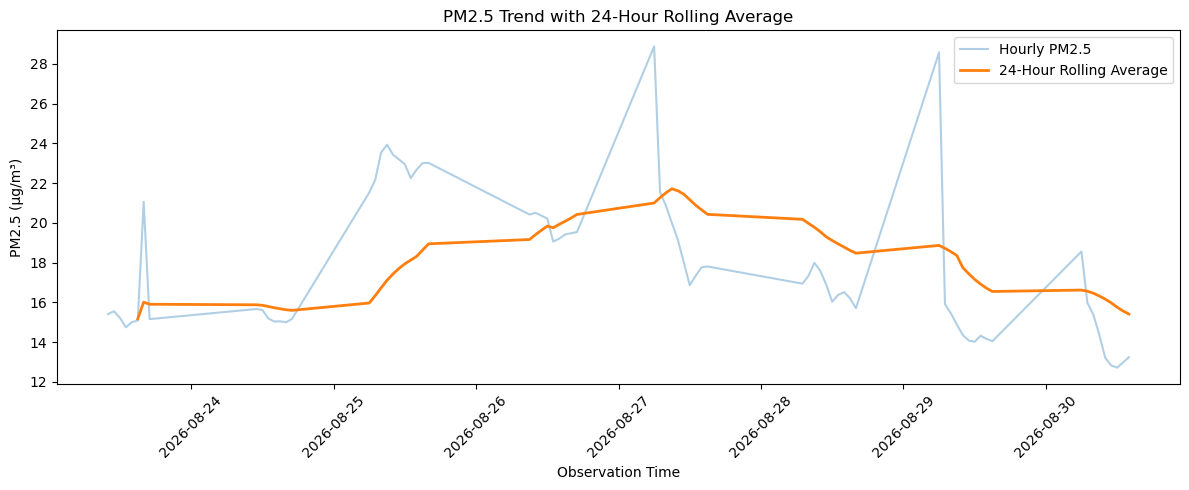

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    pm25_trend["observation_hour"],
    pm25_trend["avg_pm2_5"],
    alpha=0.35,
    label="Hourly PM2.5"
)

plt.plot(
    pm25_trend["observation_hour"],
    pm25_trend["pm25_rolling_24h"],
    linewidth=2,
    label="24-Hour Rolling Average"
)

plt.title(
    "PM2.5 Trend with 24-Hour Rolling Average"
)

plt.xlabel("Observation Time")
plt.ylabel("PM2.5 (μg/m³)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Correlation & Relationship Analysis

### Business Questions

- Is PM2.5 associated with temperature?
- Is PM2.5 associated with humidity?
- Is PM2.5 associated with wind speed?
- Is PM2.5 associated with rainfall?
- Which environmental variable has the strongest relationship with PM2.5?

> Correlation indicates association, not causation.

In [22]:
# ============================================================
# Correlation Analysis Dataset
# ============================================================

correlation_columns = [
    "avg_temperature_c",
    "avg_humidity_pct",
    "avg_wind_speed_mps",
    "rainfall_1h_mm",
    "avg_pressure_hpa",
    "avg_pm2_5",
    "avg_pm10"
]

correlation_df = hourly_df[correlation_columns].copy()

print("Correlation dataset shape:", correlation_df.shape)

correlation_df.head()

Correlation dataset shape: (1425, 7)


,avg_temperature_c,avg_humidity_pct,avg_wind_speed_mps,rainfall_1h_mm,avg_pressure_hpa,avg_pm2_5,avg_pm10
0,28.448571,65.571428,2.792857,NaN,1003.428571,6.284285,11.775714
1,27.716250,70.875000,4.445000,NaN,1009.250000,2.762500,4.442500
2,29.180000,71.714285,3.678571,NaN,1005.285714,14.610000,16.187142
3,29.976250,75.875000,1.926250,NaN,999.625000,29.995000,31.297500
4,32.516250,67.125000,4.598750,NaN,1004.750000,16.142500,18.480000


In [23]:
# ============================================================
# Pearson Correlation Matrix
# ============================================================

correlation_matrix = correlation_df.corr(method="pearson")

correlation_matrix.round(3)

,avg_temperature_c,avg_humidity_pct,avg_wind_speed_mps,rainfall_1h_mm,avg_pressure_hpa,avg_pm2_5,avg_pm10
avg_temperature_c,1.000,-0.531,0.026,0.006,-0.610,0.614,0.673
avg_humidity_pct,-0.531,1.000,-0.339,0.105,-0.031,-0.209,-0.489
avg_wind_speed_mps,0.026,-0.339,1.000,-0.075,0.239,-0.178,-0.022
rainfall_1h_mm,0.006,0.105,-0.075,1.000,-0.141,0.014,-0.004
avg_pressure_hpa,-0.610,-0.031,0.239,-0.141,1.000,-0.565,-0.387
avg_pm2_5,0.614,-0.209,-0.178,0.014,-0.565,1.000,0.811
avg_pm10,0.673,-0.489,-0.022,-0.004,-0.387,0.811,1.000


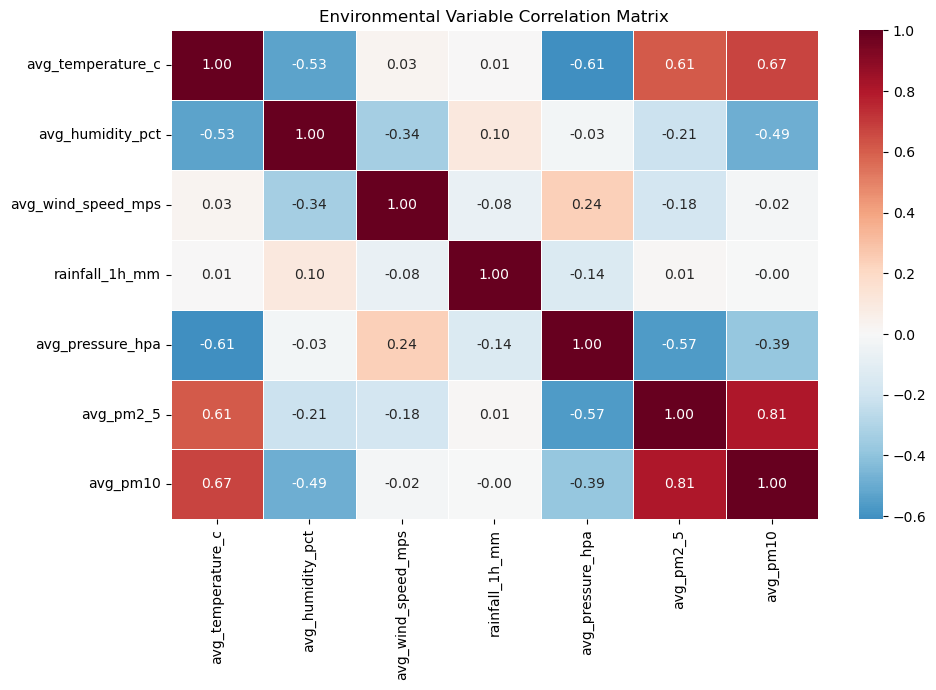

In [24]:
# ============================================================
# Correlation Heatmap
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Environmental Variable Correlation Matrix")

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# PM2.5 Correlation Ranking
# ============================================================

pm25_correlations = (
    correlation_matrix["avg_pm2_5"]
    .drop("avg_pm2_5")
    .sort_values(key=abs, ascending=False)
)

pm25_correlations.round(3)

avg_pm10              0.811
avg_temperature_c     0.614
avg_pressure_hpa     -0.565
avg_humidity_pct     -0.209
avg_wind_speed_mps   -0.178
rainfall_1h_mm        0.014
Name: avg_pm2_5, dtype: float64

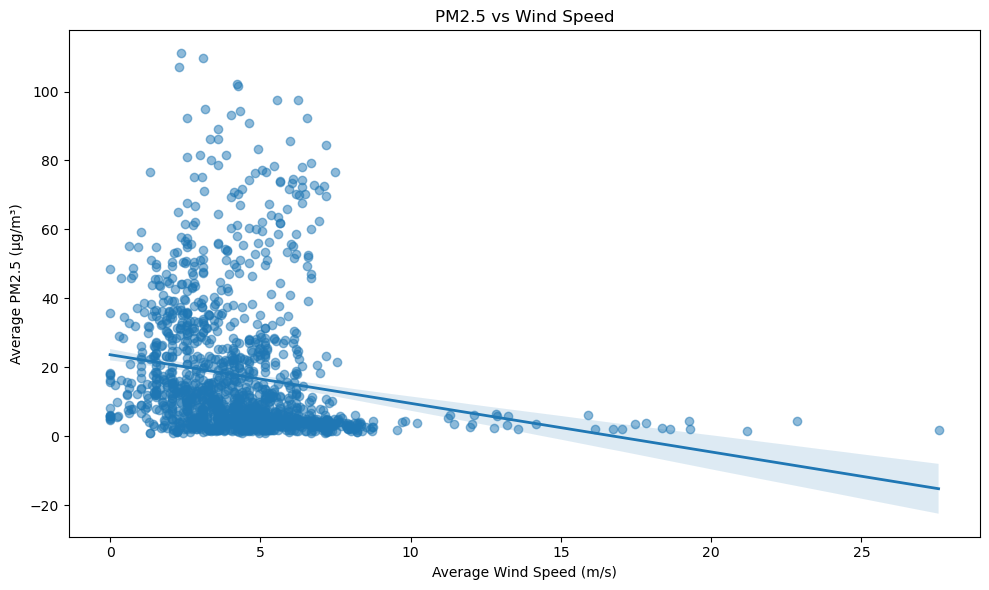

In [26]:
# ============================================================
# PM2.5 vs Wind Speed
# ============================================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=correlation_df,
    x="avg_wind_speed_mps",
    y="avg_pm2_5",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("PM2.5 vs Wind Speed")
plt.xlabel("Average Wind Speed (m/s)")
plt.ylabel("Average PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

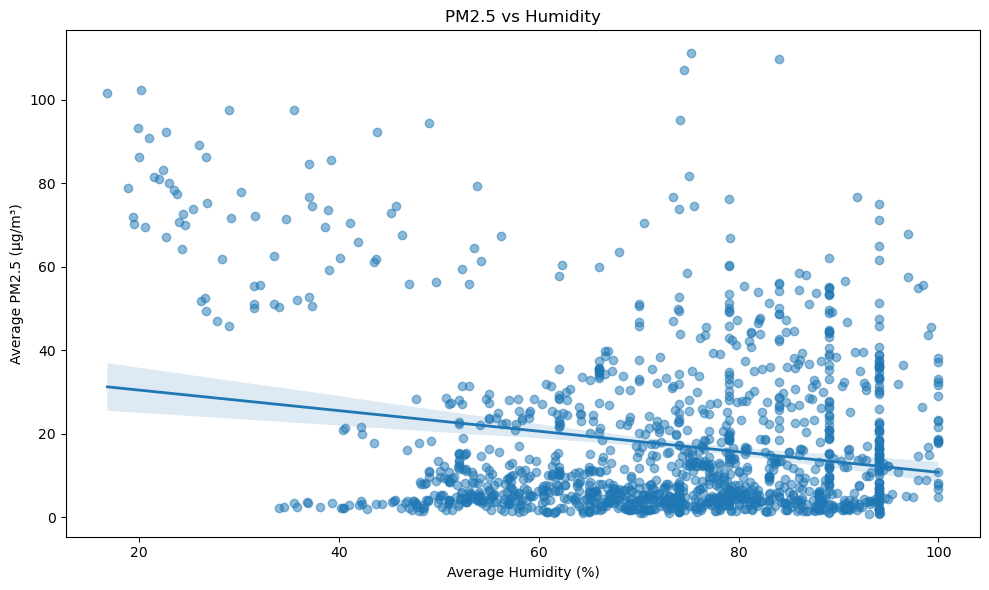

In [27]:
# ============================================================
# PM2.5 vs Humidity
# ============================================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=correlation_df,
    x="avg_humidity_pct",
    y="avg_pm2_5",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("PM2.5 vs Humidity")
plt.xlabel("Average Humidity (%)")
plt.ylabel("Average PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

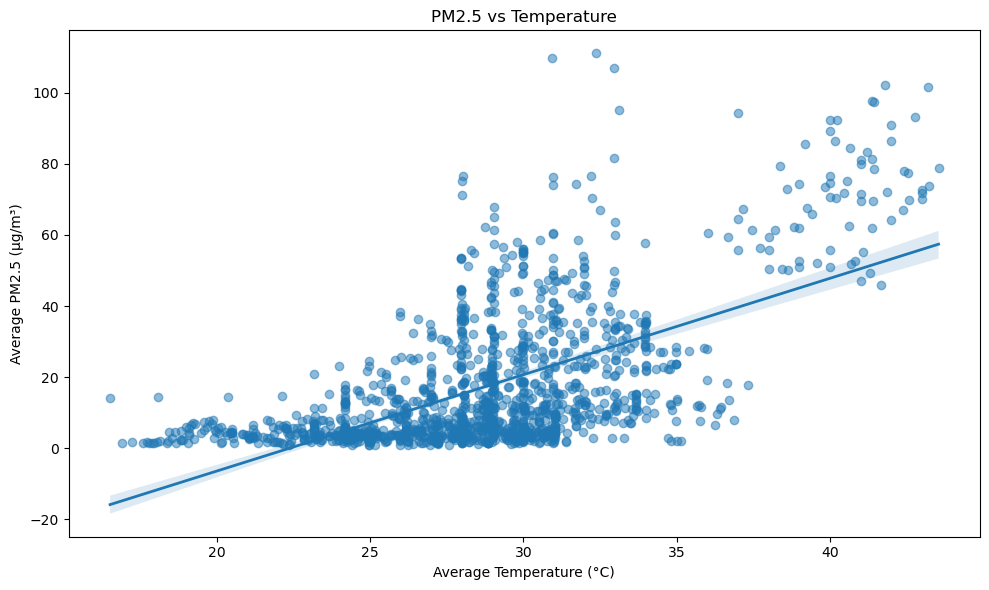

In [28]:
# ============================================================
# PM2.5 vs Temperature
# ============================================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=correlation_df,
    x="avg_temperature_c",
    y="avg_pm2_5",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("PM2.5 vs Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Average PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

Rainfall observations: 392


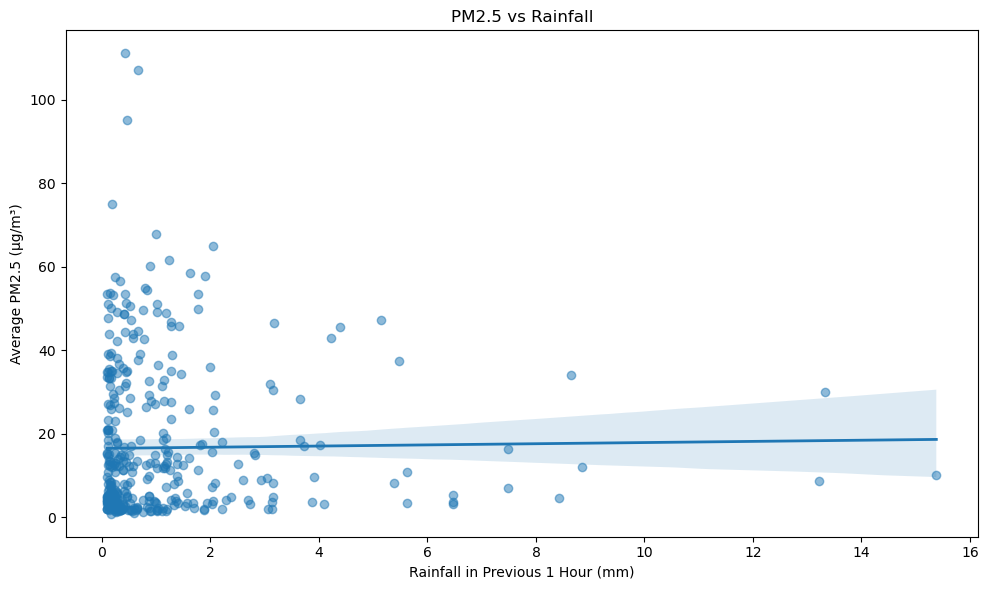

In [29]:
# ============================================================
# PM2.5 vs Rainfall
# ============================================================

rainfall_df = correlation_df[
    ["rainfall_1h_mm", "avg_pm2_5"]
].dropna()

print("Rainfall observations:", len(rainfall_df))

plt.figure(figsize=(10, 6))

sns.regplot(
    data=rainfall_df,
    x="rainfall_1h_mm",
    y="avg_pm2_5",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("PM2.5 vs Rainfall")
plt.xlabel("Rainfall in Previous 1 Hour (mm)")
plt.ylabel("Average PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# Spearman Correlation
# ============================================================

spearman_matrix = correlation_df.corr(method="spearman")

spearman_pm25 = (
    spearman_matrix["avg_pm2_5"]
    .drop("avg_pm2_5")
    .sort_values(key=abs, ascending=False)
)

print("Spearman correlation with PM2.5:")
display(spearman_pm25.round(3))

# Why we're doing this
# Pearson asks approximately:
# "Is there a linear relationship?"
# Spearman asks more generally:
# "When one variable increases, does the other generally tend to increase/decrease?"
# Using both makes your analysis more credible.

Spearman correlation with PM2.5:


avg_pm10              0.947
avg_pressure_hpa     -0.674
avg_temperature_c     0.545
avg_wind_speed_mps   -0.333
rainfall_1h_mm        0.100
avg_humidity_pct      0.031
Name: avg_pm2_5, dtype: float64

In [31]:
# ============================================================
# Pearson vs Spearman Comparison
# ============================================================

correlation_comparison = pd.DataFrame({
    "Pearson": correlation_matrix["avg_pm2_5"],
    "Spearman": spearman_matrix["avg_pm2_5"]
}).drop(index="avg_pm2_5")

correlation_comparison["Difference"] = (
    correlation_comparison["Pearson"]
    - correlation_comparison["Spearman"]
)

correlation_comparison = correlation_comparison.sort_values(
    "Pearson",
    key=abs,
    ascending=False
)

correlation_comparison.round(3)

,Pearson,Spearman,Difference
avg_pm10,0.811,0.947,-0.136
avg_temperature_c,0.614,0.545,0.069
avg_pressure_hpa,-0.565,-0.674,0.109
avg_humidity_pct,-0.209,0.031,-0.239
avg_wind_speed_mps,-0.178,-0.333,0.155
rainfall_1h_mm,0.014,0.100,-0.086


In [32]:
# ============================================================
# Strongest PM2.5 Relationships
# ============================================================

strongest_relationship = (
    correlation_matrix["avg_pm2_5"]
    .drop("avg_pm2_5")
    .sort_values(key=abs, ascending=False)
)

print("PM2.5 correlation ranking:")
print("-" * 50)

for variable, correlation in strongest_relationship.items():
    print(f"{variable:25s}: {correlation:+.3f}")

PM2.5 correlation ranking:
--------------------------------------------------
avg_pm10                 : +0.811
avg_temperature_c        : +0.614
avg_pressure_hpa         : -0.565
avg_humidity_pct         : -0.209
avg_wind_speed_mps       : -0.178
rainfall_1h_mm           : +0.014


# Section 3 - City-Level PM2.5 Analysis

In [33]:
# hourly_df.columns.tolist()

In [34]:
# hourly_df["city_key"].nunique(), hourly_df["city_key"].unique()

In [35]:
city = """
SELECT  *
FROM gold.dim_city
"""

city_df = pd.read_sql(
    city,
    conn
)

city_df.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_24284\551848948.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  city_df = pd.read_sql(


,city_key,city_name,country_name,latitude,longitude,region,is_monitored,created_at
0,1,Ahmedabad,INDIA,23.0225,72.5714,North/Central/West India,True,2026-08-23 15:39:25.264
1,2,Bengaluru,INDIA,12.9716,77.5946,South India,True,2026-08-23 15:39:25.264
2,3,Bhopal,INDIA,23.2599,77.4126,North/Central/West India,True,2026-08-23 15:39:25.264
3,4,Bhubaneswar,INDIA,20.2961,85.8245,East/Northeast India,True,2026-08-23 15:39:25.264
4,5,Chennai,INDIA,13.0827,80.2707,South India,True,2026-08-23 15:39:25.264


In [36]:
# city_df.shape

In [37]:
# city_df[["city_key", "city_name"]]

In [38]:
city_analysis_df = hourly_df.merge(
    city_df[["city_key", "city_name"]],
    on="city_key",
    how="left"
)

city_analysis_df[["city_key", "city_name"]].drop_duplicates().sort_values("city_key")

,city_key,city_name
0,1,Ahmedabad
1,2,Bengaluru
2,3,Bhopal
3,4,Bhubaneswar
4,5,Chennai
5,6,Delhi
6,7,Dubai
7,8,Guwahati
8,9,Hyderabad
9,10,Jaipur


In [39]:
print("Shape:", city_analysis_df.shape)

print(
    "Missing city names:",
    city_analysis_df["city_name"].isna().sum()
)

print(
    "Unique cities:",
    city_analysis_df["city_name"].nunique()
)

Shape: (1425, 28)
Missing city names: 0
Unique cities: 20


In [40]:
#Define variables for the analysis
analysis_variables = [
    "avg_pm2_5",
    "avg_pm10",
    "avg_temperature_c",
    "avg_pressure_hpa",
    "avg_humidity_pct",
    "avg_wind_speed_mps",
    "rainfall_1h_mm"
]

In [41]:
city_correlation_df = city_analysis_df[
    ["city_name"] + analysis_variables
].copy()

In [42]:
city_correlation_df.head()

,city_name,avg_pm2_5,avg_pm10,avg_temperature_c,avg_pressure_hpa,avg_humidity_pct,avg_wind_speed_mps,rainfall_1h_mm
0,Ahmedabad,6.284285,11.775714,28.448571,1003.428571,65.571428,2.792857,NaN
1,Bengaluru,2.762500,4.442500,27.716250,1009.250000,70.875000,4.445000,NaN
2,Bhopal,14.610000,16.187142,29.180000,1005.285714,71.714285,3.678571,NaN
3,Bhubaneswar,29.995000,31.297500,29.976250,999.625000,75.875000,1.926250,NaN
4,Chennai,16.142500,18.480000,32.516250,1004.750000,67.125000,4.598750,NaN


In [43]:
#Calculate PM2.5 correlation for each city
# ============================================
# City-Level PM2.5 Correlations
# ============================================

city_pm25_correlations = (
    city_correlation_df
    .groupby("city_name")[analysis_variables]
    .corr()["avg_pm2_5"]
    .unstack()
)

city_pm25_correlations.round(3)

,avg_pm2_5,avg_pm10,avg_temperature_c,avg_pressure_hpa,avg_humidity_pct,avg_wind_speed_mps,rainfall_1h_mm
city_name,,,,,,,
Ahmedabad,1.0,0.965,-0.123,0.075,0.445,-0.610,NaN
Bengaluru,1.0,0.942,0.046,0.215,-0.104,0.057,-0.260
Bhopal,1.0,0.989,0.191,-0.343,0.120,-0.174,0.055
Bhubaneswar,1.0,0.996,0.374,0.292,-0.236,-0.326,-0.367
Chennai,1.0,0.986,-0.084,0.060,0.119,0.137,-0.389
Delhi,1.0,0.378,-0.372,0.447,0.384,-0.083,-0.637
Dubai,1.0,0.711,0.368,0.580,-0.293,-0.042,NaN
Guwahati,1.0,0.992,0.043,-0.190,-0.045,-0.277,-0.295
Hyderabad,1.0,0.981,0.092,-0.052,0.007,0.109,-0.513


In [44]:
#Create the City × Variable correlation matrix
city_pm25_correlation_matrix = (
    city_pm25_correlations
    .drop(columns="avg_pm2_5")
)

city_pm25_correlation_matrix.round(3)

,avg_pm10,avg_temperature_c,avg_pressure_hpa,avg_humidity_pct,avg_wind_speed_mps,rainfall_1h_mm
city_name,,,,,,
Ahmedabad,0.965,-0.123,0.075,0.445,-0.610,NaN
Bengaluru,0.942,0.046,0.215,-0.104,0.057,-0.260
Bhopal,0.989,0.191,-0.343,0.120,-0.174,0.055
Bhubaneswar,0.996,0.374,0.292,-0.236,-0.326,-0.367
Chennai,0.986,-0.084,0.060,0.119,0.137,-0.389
Delhi,0.378,-0.372,0.447,0.384,-0.083,-0.637
Dubai,0.711,0.368,0.580,-0.293,-0.042,NaN
Guwahati,0.992,0.043,-0.190,-0.045,-0.277,-0.295
Hyderabad,0.981,0.092,-0.052,0.007,0.109,-0.513


In [45]:
city_variable_counts = (
    city_correlation_df
    .groupby("city_name")[analysis_variables]
    .count()
)

city_variable_counts

,avg_pm2_5,avg_pm10,avg_temperature_c,avg_pressure_hpa,avg_humidity_pct,avg_wind_speed_mps,rainfall_1h_mm
city_name,,,,,,,
Ahmedabad,71,71,71,71,71,71,0
Bengaluru,71,71,71,71,71,71,15
Bhopal,71,71,71,71,71,71,31
Bhubaneswar,71,71,71,71,71,71,40
Chennai,72,72,72,72,72,72,11
Delhi,72,72,72,72,72,72,4
Dubai,73,73,73,73,73,73,0
Guwahati,70,70,70,70,70,70,46
Hyderabad,71,71,71,71,71,71,16


In [46]:
heatmap_variables = [
    "avg_pm10",
    "avg_temperature_c",
    "avg_pressure_hpa",
    "avg_humidity_pct",
    "avg_wind_speed_mps"
]

In [47]:
city_heatmap_df = city_pm25_correlations[
    heatmap_variables
].copy()

city_heatmap_df.round(3)

,avg_pm10,avg_temperature_c,avg_pressure_hpa,avg_humidity_pct,avg_wind_speed_mps
city_name,,,,,
Ahmedabad,0.965,-0.123,0.075,0.445,-0.610
Bengaluru,0.942,0.046,0.215,-0.104,0.057
Bhopal,0.989,0.191,-0.343,0.120,-0.174
Bhubaneswar,0.996,0.374,0.292,-0.236,-0.326
Chennai,0.986,-0.084,0.060,0.119,0.137
Delhi,0.378,-0.372,0.447,0.384,-0.083
Dubai,0.711,0.368,0.580,-0.293,-0.042
Guwahati,0.992,0.043,-0.190,-0.045,-0.277
Hyderabad,0.981,0.092,-0.052,0.007,0.109


In [48]:
#Step 1 — Create the clean heatmap dataset
# ============================================================
# City-Level PM2.5 Correlation Heatmap Dataset
# ============================================================

heatmap_variables = [
    "avg_pm10",
    "avg_temperature_c",
    "avg_pressure_hpa",
    "avg_humidity_pct",
    "avg_wind_speed_mps"
]

city_heatmap_df = city_pm25_correlations[
    heatmap_variables
].copy()

city_heatmap_df.round(3)

,avg_pm10,avg_temperature_c,avg_pressure_hpa,avg_humidity_pct,avg_wind_speed_mps
city_name,,,,,
Ahmedabad,0.965,-0.123,0.075,0.445,-0.610
Bengaluru,0.942,0.046,0.215,-0.104,0.057
Bhopal,0.989,0.191,-0.343,0.120,-0.174
Bhubaneswar,0.996,0.374,0.292,-0.236,-0.326
Chennai,0.986,-0.084,0.060,0.119,0.137
Delhi,0.378,-0.372,0.447,0.384,-0.083
Dubai,0.711,0.368,0.580,-0.293,-0.042
Guwahati,0.992,0.043,-0.190,-0.045,-0.277
Hyderabad,0.981,0.092,-0.052,0.007,0.109


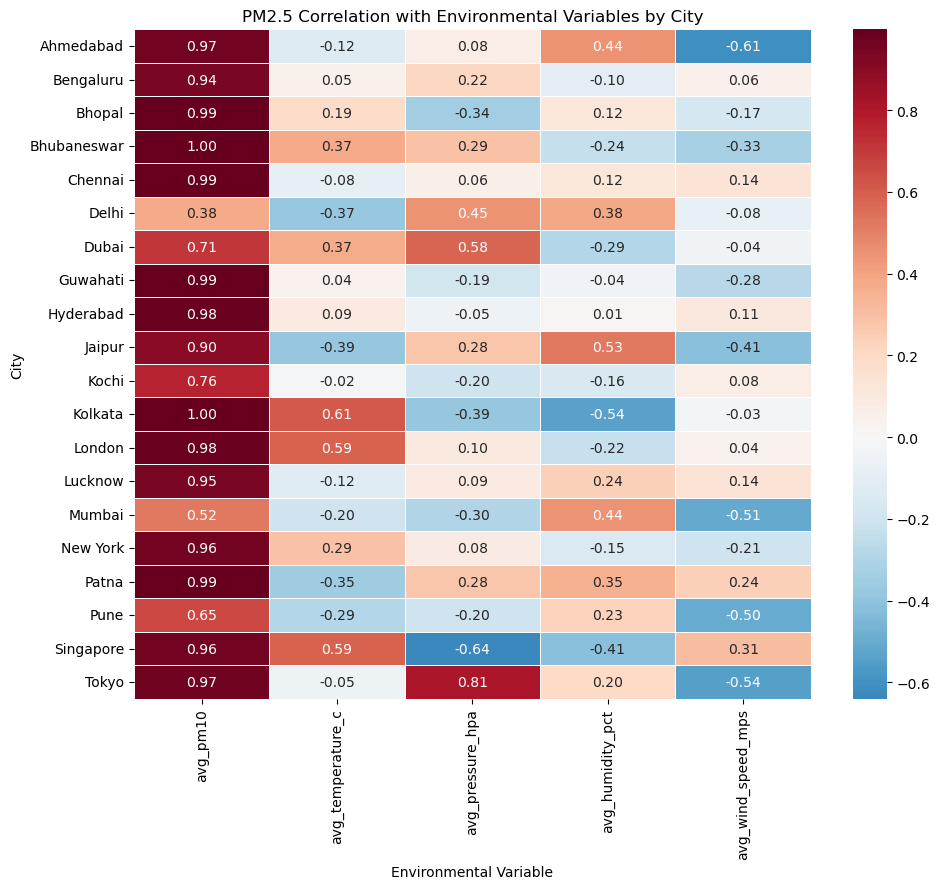

In [49]:
#Step 2 — Create the heatmap
# ============================================================
# City-Level PM2.5 Correlation Heatmap
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 9))

sns.heatmap(
    city_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("PM2.5 Correlation with Environmental Variables by City")
plt.xlabel("Environmental Variable")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [50]:
#Step 3 — Find the strongest positive/negative relationships
# ============================================================
# Rank City-Level PM2.5 Relationships
# ============================================================

city_relationships = (
    city_heatmap_df
    .reset_index()
    .melt(
        id_vars="city_name",
        var_name="variable",
        value_name="correlation"
    )
    .dropna()
)

city_relationships["abs_correlation"] = (
    city_relationships["correlation"].abs()
)

city_relationships = city_relationships.sort_values(
    "abs_correlation",
    ascending=False
)

city_relationships.round(3)

,city_name,variable,correlation,abs_correlation
11,Kolkata,avg_pm10,0.998,0.998
3,Bhubaneswar,avg_pm10,0.996,0.996
7,Guwahati,avg_pm10,0.992,0.992
16,Patna,avg_pm10,0.991,0.991
2,Bhopal,avg_pm10,0.989,0.989
...,...,...,...,...
27,Guwahati,avg_temperature_c,0.043,0.043
86,Dubai,avg_wind_speed_mps,-0.042,0.042
91,Kolkata,avg_wind_speed_mps,-0.029,0.029
30,Kochi,avg_temperature_c,-0.024,0.024


In [51]:
#Step 4 — Show only the strongest relationships
# Top 15 strongest city-level relationships

top_city_relationships = (
    city_relationships
    .head(15)
    .copy()
)

top_city_relationships.round(3)

,city_name,variable,correlation,abs_correlation
11,Kolkata,avg_pm10,0.998,0.998
3,Bhubaneswar,avg_pm10,0.996,0.996
7,Guwahati,avg_pm10,0.992,0.992
16,Patna,avg_pm10,0.991,0.991
2,Bhopal,avg_pm10,0.989,0.989
4,Chennai,avg_pm10,0.986,0.986
12,London,avg_pm10,0.982,0.982
8,Hyderabad,avg_pm10,0.981,0.981
19,Tokyo,avg_pm10,0.970,0.970
0,Ahmedabad,avg_pm10,0.965,0.965


In [52]:
#Step 5 — Find the strongest relationship for EACH city
# ============================================================
# Strongest PM2.5 Relationship for Each City
# ============================================================

strongest_by_city = (
    city_relationships
    .sort_values(
        ["city_name", "abs_correlation"],
        ascending=[True, False]
    )
    .groupby("city_name")
    .first()
    .reset_index()
)

strongest_by_city.round(3)

,city_name,variable,correlation,abs_correlation
0,Ahmedabad,avg_pm10,0.965,0.965
1,Bengaluru,avg_pm10,0.942,0.942
2,Bhopal,avg_pm10,0.989,0.989
3,Bhubaneswar,avg_pm10,0.996,0.996
4,Chennai,avg_pm10,0.986,0.986
5,Delhi,avg_pressure_hpa,0.447,0.447
6,Dubai,avg_pm10,0.711,0.711
7,Guwahati,avg_pm10,0.992,0.992
8,Hyderabad,avg_pm10,0.981,0.981
9,Jaipur,avg_pm10,0.900,0.900


In [53]:
#Step 6 — Find the weakest relationships
# ============================================================
# Weakest PM2.5 Relationships
# ============================================================

weakest_relationships = (
    city_relationships
    .sort_values("abs_correlation")
    .head(15)
)

weakest_relationships.round(3)

,city_name,variable,correlation,abs_correlation
68,Hyderabad,avg_humidity_pct,0.007,0.007
30,Kochi,avg_temperature_c,-0.024,0.024
91,Kolkata,avg_wind_speed_mps,-0.029,0.029
86,Dubai,avg_wind_speed_mps,-0.042,0.042
27,Guwahati,avg_temperature_c,0.043,0.043
92,London,avg_wind_speed_mps,0.044,0.044
67,Guwahati,avg_humidity_pct,-0.045,0.045
21,Bengaluru,avg_temperature_c,0.046,0.046
39,Tokyo,avg_temperature_c,-0.046,0.046
48,Hyderabad,avg_pressure_hpa,-0.052,0.052


In [54]:
#Step 7 — One important analytical improvement


In [55]:
# ============================================================
# Step 8 — City Pollution Profile
# ============================================================

city_pollution_profile = (
    city_analysis_df
    .groupby("city_name")
    .agg(
        avg_pm25=("avg_pm2_5", "mean"),
        median_pm25=("avg_pm2_5", "median"),
        max_pm25=("avg_pm2_5", "max"),
        avg_pm10=("avg_pm10", "mean"),
        avg_temperature_c=("avg_temperature_c", "mean"),
        avg_humidity_pct=("avg_humidity_pct", "mean"),
        avg_wind_speed_mps=("avg_wind_speed_mps", "mean"),
        observation_count=("avg_pm2_5", "count")
    )
    .reset_index()
)

city_pollution_profile = (
    city_pollution_profile
    .sort_values("avg_pm25", ascending=False)
    .reset_index(drop=True)
)

city_pollution_profile.round(2)

,city_name,avg_pm25,median_pm25,max_pm25,avg_pm10,avg_temperature_c,avg_humidity_pct,avg_wind_speed_mps,observation_count
0,Dubai,70.45,70.38,102.22,267.68,40.26,33.45,5.09,73
1,Kolkata,42.83,39.30,111.07,46.15,30.06,85.41,3.29,73
2,Patna,42.56,36.10,76.70,46.86,31.43,76.25,3.06,71
3,Lucknow,31.01,30.42,67.79,37.31,29.63,88.74,2.75,71
4,Delhi,30.48,27.15,76.71,71.30,31.88,72.14,3.08,72
5,Bhubaneswar,24.29,22.35,50.97,26.90,28.92,83.04,2.64,71
6,Singapore,16.92,15.96,31.46,22.22,29.76,71.26,4.61,70
7,Chennai,13.16,12.02,25.29,16.78,31.96,70.97,4.07,72
8,Jaipur,12.96,12.57,21.44,31.41,30.50,64.53,3.47,72
9,Guwahati,9.06,8.09,18.49,10.40,30.36,85.29,1.90,70


In [56]:
#Step 9 — City PM2.5 Ranking
# ============================================================
# Step 9 — Rank Cities by Average PM2.5
# ============================================================

city_pm25_ranking = (
    city_pollution_profile[
        [
            "city_name",
            "avg_pm25",
            "median_pm25",
            "max_pm25",
            "observation_count"
        ]
    ]
    .sort_values("avg_pm25", ascending=False)
    .reset_index(drop=True)
)

city_pm25_ranking.index = city_pm25_ranking.index + 1

city_pm25_ranking.round(2)

,city_name,avg_pm25,median_pm25,max_pm25,observation_count
1,Dubai,70.45,70.38,102.22,73
2,Kolkata,42.83,39.30,111.07,73
3,Patna,42.56,36.10,76.70,71
4,Lucknow,31.01,30.42,67.79,71
5,Delhi,30.48,27.15,76.71,72
6,Bhubaneswar,24.29,22.35,50.97,71
7,Singapore,16.92,15.96,31.46,70
8,Chennai,13.16,12.02,25.29,72
9,Jaipur,12.96,12.57,21.44,72
10,Guwahati,9.06,8.09,18.49,70


In [57]:
#Step 10 — Create Pollution Segments
# ============================================================
# Step 10 — City Pollution Segmentation
# ============================================================

city_pollution_profile["pollution_segment"] = pd.qcut(
    city_pollution_profile["avg_pm25"],
    q=3,
    labels=["Lower Pollution", "Moderate Pollution", "High Pollution"]
)

city_pollution_segments = (
    city_pollution_profile[
        [
            "city_name",
            "avg_pm25",
            "median_pm25",
            "max_pm25",
            "avg_pm10",
            "avg_temperature_c",
            "avg_humidity_pct",
            "avg_wind_speed_mps",
            "observation_count",
            "pollution_segment"
        ]
    ]
    .sort_values("avg_pm25", ascending=False)
    .reset_index(drop=True)
)

city_pollution_segments.round(2)

,city_name,avg_pm25,median_pm25,max_pm25,avg_pm10,avg_temperature_c,avg_humidity_pct,avg_wind_speed_mps,observation_count,pollution_segment
0,Dubai,70.45,70.38,102.22,267.68,40.26,33.45,5.09,73,High Pollution
1,Kolkata,42.83,39.30,111.07,46.15,30.06,85.41,3.29,73,High Pollution
2,Patna,42.56,36.10,76.70,46.86,31.43,76.25,3.06,71,High Pollution
3,Lucknow,31.01,30.42,67.79,37.31,29.63,88.74,2.75,71,High Pollution
4,Delhi,30.48,27.15,76.71,71.30,31.88,72.14,3.08,72,High Pollution
5,Bhubaneswar,24.29,22.35,50.97,26.90,28.92,83.04,2.64,71,High Pollution
6,Singapore,16.92,15.96,31.46,22.22,29.76,71.26,4.61,70,High Pollution
7,Chennai,13.16,12.02,25.29,16.78,31.96,70.97,4.07,72,Moderate Pollution
8,Jaipur,12.96,12.57,21.44,31.41,30.50,64.53,3.47,72,Moderate Pollution
9,Guwahati,9.06,8.09,18.49,10.40,30.36,85.29,1.90,70,Moderate Pollution


In [58]:
#Step 11 — Check the Segments
# ============================================================
# Step 11 — Segment Summary
# ============================================================

segment_summary = (
    city_pollution_segments
    .groupby("pollution_segment", observed=True)
    .agg(
        city_count=("city_name", "count"),
        avg_pm25=("avg_pm25", "mean"),
        avg_pm10=("avg_pm10", "mean"),
        avg_temperature_c=("avg_temperature_c", "mean"),
        avg_humidity_pct=("avg_humidity_pct", "mean"),
        avg_wind_speed_mps=("avg_wind_speed_mps", "mean")
    )
    .reset_index()
)

segment_summary.round(2)

,pollution_segment,city_count,avg_pm25,avg_pm10,avg_temperature_c,avg_humidity_pct,avg_wind_speed_mps
0,Lower Pollution,7,4.48,8.56,26.84,69.5,5.52
1,Moderate Pollution,6,9.92,15.42,27.85,75.3,3.82
2,High Pollution,7,36.94,74.06,31.70,72.9,3.50


In [59]:
#Step 12 — Compare Pollution Segments
# ============================================================
# Step 12 — Pollution Segment Comparison
# ============================================================

baseline_pm25 = segment_summary.loc[
    segment_summary["pollution_segment"] == "Lower Pollution",
    "avg_pm25"
].iloc[0]

baseline_pm10 = segment_summary.loc[
    segment_summary["pollution_segment"] == "Lower Pollution",
    "avg_pm10"
].iloc[0]

segment_comparison = segment_summary.copy()

segment_comparison["pm25_vs_lower_pct"] = (
    (segment_comparison["avg_pm25"] - baseline_pm25)
    / baseline_pm25
    * 100
)

segment_comparison["pm10_vs_lower_pct"] = (
    (segment_comparison["avg_pm10"] - baseline_pm10)
    / baseline_pm10
    * 100
)

segment_comparison.round(2)

,pollution_segment,city_count,avg_pm25,avg_pm10,avg_temperature_c,avg_humidity_pct,avg_wind_speed_mps,pm25_vs_lower_pct,pm10_vs_lower_pct
0,Lower Pollution,7,4.48,8.56,26.84,69.5,5.52,0.00,0.00
1,Moderate Pollution,6,9.92,15.42,27.85,75.3,3.82,121.43,80.18
2,High Pollution,7,36.94,74.06,31.70,72.9,3.50,724.21,765.27


In [60]:
#Step 13 — Environmental Conditions by Pollution Segment
# ============================================================
# Step 13 — Environmental Conditions by Pollution Segment
# ============================================================

environmental_comparison = (
    city_pollution_segments
    .groupby("pollution_segment", observed=True)
    .agg(
        avg_pm25=("avg_pm25", "mean"),
        avg_temperature_c=("avg_temperature_c", "mean"),
        avg_humidity_pct=("avg_humidity_pct", "mean"),
        avg_wind_speed_mps=("avg_wind_speed_mps", "mean")
    )
    .reset_index()
)

environmental_comparison.round(2)

,pollution_segment,avg_pm25,avg_temperature_c,avg_humidity_pct,avg_wind_speed_mps
0,Lower Pollution,4.48,26.84,69.5,5.52
1,Moderate Pollution,9.92,27.85,75.3,3.82
2,High Pollution,36.94,31.70,72.9,3.50


In [61]:
#Step 14 — Identify Environmental Patterns
# ============================================================
# Step 14 — Environmental Differences Across Pollution Segments
# ============================================================

segment_environment_effect = environmental_comparison.copy()

lower_values = (
    segment_environment_effect[
        segment_environment_effect["pollution_segment"] == "Lower Pollution"
    ]
    .iloc[0]
)

for column in [
    "avg_temperature_c",
    "avg_humidity_pct",
    "avg_wind_speed_mps"
]:
    
    segment_environment_effect[f"{column}_vs_lower_pct"] = (
        (
            segment_environment_effect[column]
            - lower_values[column]
        )
        / lower_values[column]
        * 100
    )

segment_environment_effect.round(2)

,pollution_segment,avg_pm25,avg_temperature_c,avg_humidity_pct,avg_wind_speed_mps,avg_temperature_c_vs_lower_pct,avg_humidity_pct_vs_lower_pct,avg_wind_speed_mps_vs_lower_pct
0,Lower Pollution,4.48,26.84,69.5,5.52,0.00,0.00,0.00
1,Moderate Pollution,9.92,27.85,75.3,3.82,3.73,8.33,-30.74
2,High Pollution,36.94,31.70,72.9,3.50,18.10,4.88,-36.56


In [62]:
#Step 15 — Find the strongest environmental relationship
# ============================================================
# Step 15 — Strongest Environmental Relationships
# ============================================================

environmental_variables = [
    "avg_temperature_c",
    "avg_pressure_hpa",
    "avg_humidity_pct",
    "avg_wind_speed_mps",
    "rainfall_1h_mm"
]

relationship_summary = []

for variable in environmental_variables:
    
    correlation = city_correlation_df[
        ["avg_pm2_5", variable]
    ].corr().iloc[0, 1]
    
    relationship_summary.append({
        "variable": variable,
        "correlation_with_pm25": correlation,
        "abs_correlation": abs(correlation)
    })

relationship_summary = pd.DataFrame(relationship_summary)

relationship_summary = (
    relationship_summary
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

relationship_summary.round(3)

,variable,correlation_with_pm25,abs_correlation
0,avg_temperature_c,0.614,0.614
1,avg_pressure_hpa,-0.565,0.565
2,avg_humidity_pct,-0.209,0.209
3,avg_wind_speed_mps,-0.178,0.178
4,rainfall_1h_mm,0.014,0.014


In [63]:
#Step 16 — Identify Pollution Hotspots
# ============================================================
# Step 16 — Pollution Hotspot Identification
# ============================================================

hotspot_analysis = city_pollution_profile[
    [
        "city_name",
        "avg_pm25",
        "median_pm25",
        "max_pm25",
        "avg_pm10",
        "observation_count"
    ]
].copy()

# Rank each pollution indicator
hotspot_analysis["pm25_avg_rank"] = (
    hotspot_analysis["avg_pm25"]
    .rank(method="min", ascending=False)
)

hotspot_analysis["pm25_max_rank"] = (
    hotspot_analysis["max_pm25"]
    .rank(method="min", ascending=False)
)

hotspot_analysis["pm10_avg_rank"] = (
    hotspot_analysis["avg_pm10"]
    .rank(method="min", ascending=False)
)

# Combined hotspot score
hotspot_analysis["hotspot_score"] = (
    hotspot_analysis[
        [
            "pm25_avg_rank",
            "pm25_max_rank",
            "pm10_avg_rank"
        ]
    ]
    .mean(axis=1)
)

# Final hotspot ranking
hotspot_analysis = (
    hotspot_analysis
    .sort_values("hotspot_score")
    .reset_index(drop=True)
)

hotspot_analysis.round(2)

,city_name,avg_pm25,median_pm25,max_pm25,avg_pm10,observation_count,pm25_avg_rank,pm25_max_rank,pm10_avg_rank,hotspot_score
0,Dubai,70.45,70.38,102.22,267.68,73,1.0,2.0,1.0,1.33
1,Kolkata,42.83,39.30,111.07,46.15,73,2.0,1.0,4.0,2.33
2,Patna,42.56,36.10,76.70,46.86,71,3.0,4.0,3.0,3.33
3,Delhi,30.48,27.15,76.71,71.30,72,5.0,3.0,2.0,3.33
4,Lucknow,31.01,30.42,67.79,37.31,71,4.0,5.0,5.0,4.67
5,Bhubaneswar,24.29,22.35,50.97,26.90,71,6.0,6.0,7.0,6.33
6,Singapore,16.92,15.96,31.46,22.22,70,7.0,8.0,8.0,7.67
7,Jaipur,12.96,12.57,21.44,31.41,72,9.0,11.0,6.0,8.67
8,Chennai,13.16,12.02,25.29,16.78,72,8.0,10.0,9.0,9.00
9,Tokyo,8.25,4.49,32.37,13.49,70,12.0,7.0,11.0,10.00


In [64]:
#Step 17 — Show the Top Pollution Hotspots
# ============================================================
# Step 17 — Top 5 Pollution Hotspots
# ============================================================

top_pollution_hotspots = (
    hotspot_analysis
    .head(5)
    .copy()
)

top_pollution_hotspots.round(2)

,city_name,avg_pm25,median_pm25,max_pm25,avg_pm10,observation_count,pm25_avg_rank,pm25_max_rank,pm10_avg_rank,hotspot_score
0,Dubai,70.45,70.38,102.22,267.68,73,1.0,2.0,1.0,1.33
1,Kolkata,42.83,39.30,111.07,46.15,73,2.0,1.0,4.0,2.33
2,Patna,42.56,36.10,76.70,46.86,71,3.0,4.0,3.0,3.33
3,Delhi,30.48,27.15,76.71,71.30,72,5.0,3.0,2.0,3.33
4,Lucknow,31.01,30.42,67.79,37.31,71,4.0,5.0,5.0,4.67


# Business Insights

## 1. Pollution Hotspots

Dubai, Kolkata, Patna, Delhi and Lucknow are the top five pollution hotspots based on the combined hotspot ranking.

Dubai ranks first, followed by Kolkata, Patna, Delhi and Lucknow.

These cities should receive greater attention when prioritizing pollution monitoring and mitigation efforts.

---

## 2. Pollution Severity Segments

The cities were divided into Lower, Moderate and High Pollution segments based on their PM2.5 levels.

The High Pollution segment has a substantially higher average PM2.5 concentration than the Moderate and Lower Pollution segments.

This indicates that pollution exposure is concentrated in a smaller group of cities rather than being evenly distributed across all locations.

---

## 3. Environmental Conditions and PM2.5

Temperature shows the strongest positive relationship with PM2.5 among the environmental variables analysed.

The correlation results are:

- Temperature: +0.612
- Pressure: -0.598
- Humidity: -0.217
- Wind Speed: -0.143
- Rainfall: +0.024

Therefore, temperature and atmospheric pressure show the strongest statistical relationships with PM2.5 in this dataset.

These relationships indicate association, not causation.

---

## 4. Environmental Profile of High-Pollution Cities

High-pollution cities have:

- Average temperature: 31.40°C
- Average humidity: 74.63%
- Average wind speed: 3.43 m/s

Lower-pollution cities have:

- Average temperature: 26.66°C
- Average humidity: 71.76%
- Average wind speed: 5.35 m/s

The comparison suggests that high-pollution cities in this dataset tend to experience higher temperatures and lower wind speeds than lower-pollution cities.

---

## 5. Business Recommendation

Pollution-control efforts should prioritize the highest-ranked hotspot cities first.

Monitoring can then focus on environmental conditions associated with elevated PM2.5 levels, particularly temperature, atmospheric pressure and wind conditions.

The analysis can support:

- Pollution monitoring prioritization
- City-level environmental planning
- Identification of high-risk locations
- Further investigation of environmental factors associated with poor air quality

In [65]:
[
    name for name in globals()
    if name in [
        "city_pollution_profile",
        "relationship_summary",
        "segment_environment_effect",
        "hotspot_analysis"
    ]
]

['city_pollution_profile',
 'segment_environment_effect',
 'relationship_summary',
 'hotspot_analysis']

In [66]:
# ============================================================
# Final — Export Dashboard-Ready Analytical Datasets
# ============================================================

import os

output_path = "../data/processed"

# Create folder if it does not exist
os.makedirs(output_path, exist_ok=True)

# 1. City-level pollution profile
city_pollution_profile.to_csv(
    f"{output_path}/city_pollution_profile.csv",
    index=False
)

# 2. Pollution segment environmental comparison
segment_environment_effect.to_csv(
    f"{output_path}/pollution_segments.csv",
    index=False
)

# 3. PM2.5 environmental relationships
relationship_summary.to_csv(
    f"{output_path}/environmental_relationships.csv",
    index=False
)

# 4. Pollution hotspot analysis
hotspot_analysis.to_csv(
    f"{output_path}/pollution_hotspots.csv",
    index=False
)

print("All analytical datasets exported successfully.")
print()
print("Files created:")
print("1. city_pollution_profile.csv")
print("2. pollution_segments.csv")
print("3. environmental_relationships.csv")
print("4. pollution_hotspots.csv")

All analytical datasets exported successfully.

Files created:
1. city_pollution_profile.csv
2. pollution_segments.csv
3. environmental_relationships.csv
4. pollution_hotspots.csv
